# Fractal SNN Packet Demo

This notebook demonstrates the v0 packet layer for matrix fractal numbers.

```text
PREAMBLE -> START_DELIMITER -> SIGN -> PAYLOAD_START_GUARD -> FRACTAL_PAYLOAD -> END_GUARD -> END_DELIMITER -> CHECK
```

The packet layer is intentionally separate from the fractal payload math. Service fields synchronize and frame the event stream; `MatrixFractalNumber` still defines the numeric payload.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

ROOT = Path.cwd()
if ROOT.name == "experiments":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

from snn_framework import FractalSNNPacketCodec, MatrixFractalNumber

number = MatrixFractalNumber(period_levels=2, shift_levels=4)
codec = FractalSNNPacketCodec(number)
examples = [(37, 2), (-2026, 4)]

## Service Fields

- `PREAMBLE`: receiver activation and local tick synchronization.
- `START_DELIMITER`: unique packet start marker.
- `SIGN`: sign-magnitude code; `10` is positive, `01` is negative, `11` is zero/special.
- `PAYLOAD_START_GUARD`: silence before local payload tick zero.
- `FRACTAL_PAYLOAD`: summed matrix fractal number signal.
- `END_GUARD`: silence before the packet end marker.
- `END_DELIMITER`: self-delimiting packet end marker.
- `CHECK`: `sum(payload_digits) mod base`.

In [2]:
def field_table(encoded):
    return pd.DataFrame(
        [
            {
                "Field": field.name,
                "Ticks": f"{field.start_tick}:{field.end_tick}",
                "Pattern": "payload" if field.pattern is None else "".join(str(bit) for bit in field.pattern),
                "Description": field.description,
            }
            for field in encoded.fields
        ]
    )


def cell_table(encoded):
    rows = []
    for cell in encoded.payload_cells:
        rows.append(
            {
                "Channel": cell.digit_index,
                "Role": "LSF" if cell.digit_index == 0 else "MSF" if cell.digit_index == encoded.digit_count - 1 else "middle",
                "Digit": cell.digit_value,
                "Period_index": cell.period_index,
                "Shift_index": cell.shift_index,
                "Period": cell.period_ticks,
                "Shift": cell.shift_ticks,
                "Active_half_period": cell.active_width_ticks,
            }
        )
    return pd.DataFrame(rows)


def signal_table(encoded, head=80):
    rows = [
        {
            "Tick": sample.tick,
            "Field": sample.field_name,
            "Packet_amplitude": sample.total_amplitude,
            "Payload_amplitude": sample.payload_amplitude,
        }
        for sample in encoded.samples[:head]
    ]
    return pd.DataFrame(rows)

## Encode Two Values

`37` uses two payload digits in base `8`; `-2026` uses four digits and demonstrates the sign field.

In [3]:
encoded_packets = []
for value, digit_count in examples:
    encoded = codec.encode(value, digit_count=digit_count)
    encoded_packets.append(encoded)
    print(f"value={value}, sign={encoded.sign}, abs={encoded.absolute_value}, digits={encoded.payload_digits}, check={encoded.check_value}")

value=37, sign=1, abs=37, digits=(5, 4), check=1
value=-2026, sign=-1, abs=2026, digits=(2, 5, 7, 3), check=1


In [4]:
for encoded in encoded_packets:
    print(f"\nPacket fields for value={encoded.value}")
    display(field_table(encoded))
    print(f"Payload generator cells for value={encoded.value}")
    display(cell_table(encoded))


Packet fields for value=37


,Field,Ticks,Pattern,Description
0,PREAMBLE,0:8,10101010,receiver activation and local tick synchroniza...
1,START_DELIMITER,8:15,1110010,unique packet start marker
2,SIGN,15:17,10,sign-magnitude sign code
3,PAYLOAD_START_GUARD,17:21,0000,guard interval before payload_tick = 0
4,FRACTAL_PAYLOAD,21:54,payload,summed matrix fractal number payload
5,END_GUARD,54:58,0000,guard interval after fractal payload
6,END_DELIMITER,58:65,1001110,self-delimiting packet end marker
7,CHECK,65:68,001,sum(payload digits) mod base


Payload generator cells for value=37


,Channel,Role,Digit,Period_index,Shift_index,Period,Shift,Active_half_period
0,0,LSF,5,1,1,16,4,8
1,1,MSF,4,1,0,32,0,16



Packet fields for value=-2026


,Field,Ticks,Pattern,Description
0,PREAMBLE,0:8,10101010,receiver activation and local tick synchroniza...
1,START_DELIMITER,8:15,1110010,unique packet start marker
2,SIGN,15:17,01,sign-magnitude sign code
3,PAYLOAD_START_GUARD,17:21,0000,guard interval before payload_tick = 0
4,FRACTAL_PAYLOAD,21:120,payload,summed matrix fractal number payload
5,END_GUARD,120:124,0000,guard interval after fractal payload
6,END_DELIMITER,124:131,1001110,self-delimiting packet end marker
7,CHECK,131:134,001,sum(payload digits) mod base


Payload generator cells for value=-2026


,Channel,Role,Digit,Period_index,Shift_index,Period,Shift,Active_half_period
0,0,LSF,2,0,2,8,4,4
1,1,middle,5,1,1,32,8,16
2,2,middle,7,1,3,48,36,24
3,3,MSF,3,0,3,56,42,28


## Packet Signal

The service fields are binary slots. The payload field is the summed amplitude signal produced by `MatrixFractalNumber.signal()`.


First packet samples for value=37


,Tick,Field,Packet_amplitude,Payload_amplitude
0,0,PREAMBLE,1.0,0.0
1,1,PREAMBLE,0.0,0.0
2,2,PREAMBLE,1.0,0.0
3,3,PREAMBLE,0.0,0.0
4,4,PREAMBLE,1.0,0.0
...,...,...,...,...
63,63,END_DELIMITER,1.0,0.0
64,64,END_DELIMITER,0.0,0.0
65,65,CHECK,0.0,0.0
66,66,CHECK,0.0,0.0


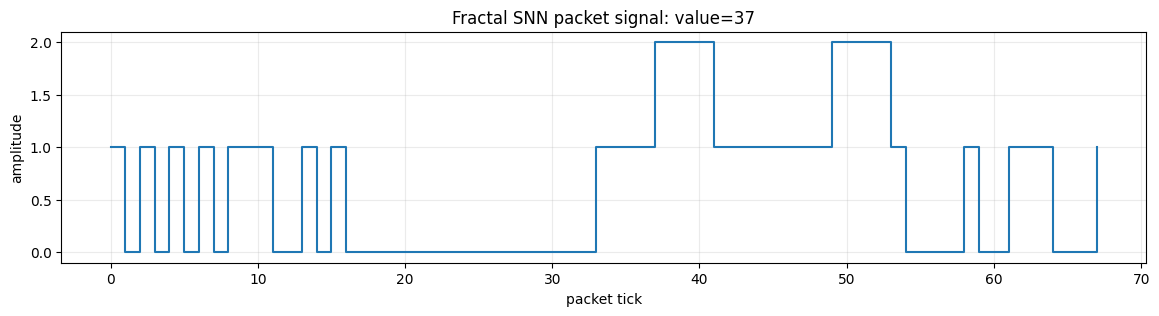


First packet samples for value=-2026


,Tick,Field,Packet_amplitude,Payload_amplitude
0,0,PREAMBLE,1.0,0.0
1,1,PREAMBLE,0.0,0.0
2,2,PREAMBLE,1.0,0.0
3,3,PREAMBLE,0.0,0.0
4,4,PREAMBLE,1.0,0.0
...,...,...,...,...
85,85,FRACTAL_PAYLOAD,3.0,3.0
86,86,FRACTAL_PAYLOAD,3.0,3.0
87,87,FRACTAL_PAYLOAD,3.0,3.0
88,88,FRACTAL_PAYLOAD,3.0,3.0


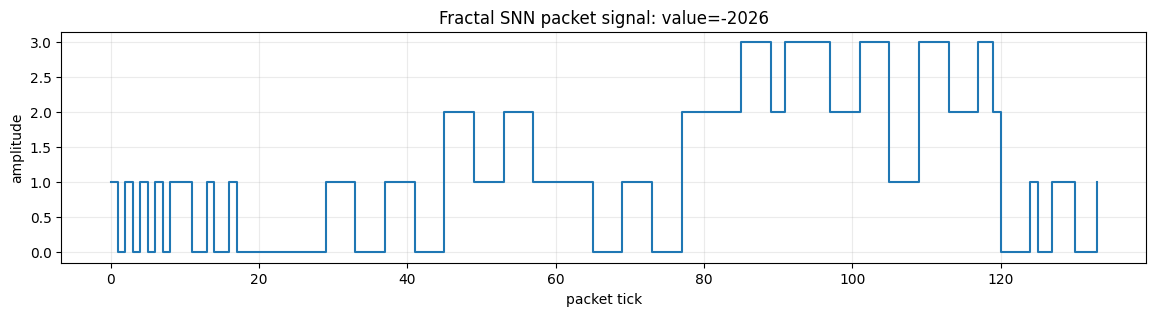

In [5]:
for encoded in encoded_packets:
    print(f"\nFirst packet samples for value={encoded.value}")
    display(signal_table(encoded, head=min(90, len(encoded.samples))))

    ticks = [sample.tick for sample in encoded.samples]
    amplitudes = [sample.total_amplitude for sample in encoded.samples]
    plt.figure(figsize=(14, 3))
    plt.step(ticks, amplitudes, where="post")
    plt.title(f"Fractal SNN packet signal: value={encoded.value}")
    plt.xlabel("packet tick")
    plt.ylabel("amplitude")
    plt.grid(True, alpha=0.25)
    plt.show()

## Decode

The decoder finds `PREAMBLE + START_DELIMITER`, reads `SIGN`, skips the payload guard, finds `END_GUARD + END_DELIMITER`, then passes only the payload slice to the summed-signal peeling decoder.

In [6]:
for encoded in encoded_packets:
    decoded = codec.decode(encoded.samples)
    print(f"value={encoded.value} -> decoded={decoded.value}")
    print(
        {
            "payload_ticks": (decoded.payload_start_tick, decoded.payload_end_tick),
            "digits": decoded.payload_digits,
            "check": decoded.check_value,
            "check_ok": decoded.check_ok,
            "cells_match": decoded.payload_cells == encoded.payload_cells,
        }
    )
    assert decoded.value == encoded.value
    assert decoded.payload_cells == encoded.payload_cells
    assert decoded.check_ok

value=37 -> decoded=37
{'payload_ticks': (21, 54), 'digits': (5, 4), 'check': 1, 'check_ok': True, 'cells_match': True}
value=-2026 -> decoded=-2026
{'payload_ticks': (21, 120), 'digits': (2, 5, 7, 3), 'check': 1, 'check_ok': True, 'cells_match': True}
